# Glass Baseline: V2, splitting G-G and G-B
This journal documents and generates the calculations supporting the splitting of the PV ICE module baseline into a glass-glass and a glass-backsheet conformation. This deconvolutes the information of the two, enabling more refined modeling.

In [1]:
import numpy as np
import pandas as pd
import os,sys
from pathlib import Path
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
import glob
#import PV_ICE
cwd = os.getcwd() #grabs current working directory

In [2]:
#print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("pyplot ", plt.matplotlib.__version__)
#print("PV_ICE version ", PV_ICE.__version__)

Python version  3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
Pandas version  2.0.3
pyplot  3.7.2


In [3]:
supportMatfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'baselines' / 'SupportingMaterial')
baselinesFolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'baselines')
cwd

'C:\\Users\\hmirletz\\Documents\\GitHub\\PV_ICE\\docs\\baseline development documentation'

In [59]:
#skipcols = ['Source', 'Source.1']
density_glass = 2500*1000 # g/m^3   
thicknesses = pd.DataFrame({'gtr3mm':3.2,
            '2to3mm':2.5,
            'less2mm':1.8}, index=['mm']) #dataframe of the glass thicknesses
glass_gpm2 = thicknesses/1000*density_glass
glass_gpm2

,gtr3mm,2to3mm,less2mm
mm,8000.0,6250.0,4500.0


In [5]:
#pd.read_csv(os.path.join(baselinesFolder, ''), index_col = 0, usecols=['year','mat_massperm2'], skiprows=[1])

#pull in the complete marketshare of module conformation and glass thickness file
glass_raw = pd.read_excel(os.path.join(supportMatfolder,'input_Marketshare_Glass_Thickness_G-GvG-B.xlsx'), 
                           index_col=0, header=[0,1])

In [16]:
glass_raw.columns
#glass_raw['Module conformation marketshare']['glass-glass'].dropna(how='all')

MultiIndex([(       'Module conformation marketshare', 'glass-backsheet'),
            (       'Module conformation marketshare',     'glass-glass'),
            (       'Module conformation marketshare',       'foil-foil'),
            (       'Module conformation marketshare',          'Source'),
            ('all conformation front glass thickness',          'gtr3mm'),
            ('all conformation front glass thickness',          '2to3mm'),
            ('all conformation front glass thickness',         'less2mm'),
            ('all conformation front glass thickness',          'Source'),
            (             'g-b front glass thickness',          'gtr3mm'),
            (             'g-b front glass thickness',          '2to3mm'),
            (             'g-b front glass thickness',         'less2mm'),
            (             'g-b front glass thickness',          'Source'),
            (             'g-g front glass thickness',          'gtr3mm'),
            (            

In [50]:
glass_data = glass_raw.drop(level=1,columns='Source', axis=1) #drop the source columns for interpolation
#glass_data
glass_filled = glass_data.interpolate(limit_direction='both') #interpolate to fill years of missing data
glass_fract = glass_filled/100 #turn % into fractions
glass_fract

Module conformation marketshare                        \
Year                 glass-backsheet glass-glass foil-foil   
1995                        1.000000    0.000000  0.000000   
1996                        1.000000    0.000000  0.000000   
1997                        1.000000    0.000000  0.000000   
1998                        1.000000    0.000000  0.000000   
1999                        1.000000    0.000000  0.000000   
2000                        1.000000    0.000000  0.000000   
2001                        1.000000    0.000000  0.000000   
2002                        1.000000    0.000000  0.000000   
2003                        1.000000    0.000000  0.000000   
2004                        1.000000    0.000000  0.000000   
2005                        1.000000    0.000000  0.000000   
2006                        1.000000    0.000000  0.000000   
2007                        1.000000    0.000000  0.000000   
2008                        1.000000    0.000000  0.000000   
2009                        1.000000    0.000000  0.000000   
2010                        1.000000    0.000000  0.000000   
2011                        1.000000    0.000000  0.000000   
2012                        0.990000    0.010000  0.000000   
2013                        0.980000    0.020000  0.000000   
2014                        0.960000    0.040000  0.000000   
2015                        0.980000    0.020000  0.000000   
2016                        0.970000    0.030000  0.000000   
2017                        0.950000    0.050000  0.000000   
2018                        0.940000    0.060000  0.000000   
2019                        0.900000    0.100000  0.000000   
2020                        0.840000    0.160000  0.000000   
2021                        0.745000    0.250000  0.005000   
2022                        0.670000    0.330000  0.000000   
2023                        0.590000    0.400000  0.010000   
2024                        0.460000    0.530000  0.010000   
2025                        0.420000    0.565000  0.015000   
2026                        0.380000    0.600000  0.020000   
2027                        0.340000    0.640000  0.020000   
2028                        0.300000    0.680000  0.020000   
2029                        0.283333    0.693333  0.023333   
2030                        0.266667    0.706667  0.026667   
2031                        0.250000    0.720000  0.030000   
2032                        0.243333    0.723333  0.033333   
2033                        0.236667    0.726667  0.036667   
2034                        0.230000    0.730000  0.040000   
2035                        0.230000    0.730000  0.040000   
2036                        0.230000    0.730000  0.040000   
2037                        0.230000    0.730000  0.040000   
2038                        0.230000    0.730000  0.040000   
2039                        0.230000    0.730000  0.040000   
2040                        0.230000    0.730000  0.040000   
2041                        0.230000    0.730000  0.040000   
2042                        0.230000    0.730000  0.040000   
2043                        0.230000    0.730000  0.040000   
2044                        0.230000    0.730000  0.040000   
2045                        0.230000    0.730000  0.040000   
2046                        0.230000    0.730000  0.040000   
2047                        0.230000    0.730000  0.040000   
2048                        0.230000    0.730000  0.040000   
2049                        0.230000    0.730000  0.040000   
2050                        0.230000    0.730000  0.040000   

     all conformation front glass thickness                 \
Year                                 gtr3mm 2to3mm less2mm   
1995                                   1.00   0.00    0.00   
1996                                   1.00   0.00    0.00   
1997                                   1.00   0.00    0.00   
1998                                   1.00   0.00    0.00   
1999                                

## Glass-Backsheet Glass Intensity
Early modules were mostly glass-backsheet, but marketshare has decreased over time. Most front glass is the 3.2mm, but marketshare of 2.5mm has been increasing. We will multiply the thicknesses by glass density and marketshare to get an average glass intensity for a module by year:

    avg_glassperm2 = SUM(thickness_glass * density_glass * marketshare)

In [70]:
#multiply each thickness by density to get fraction of mass per m2
g_b_frontglassmass = glass_fract['g-b front glass thickness']*glass_gpm2.values
g_b_glassMass = g_b_frontglassmass.sum(axis=1)

## Glass-Glass Glass Intensity
This is becoming the dominant technology. We assume in early years that both front and back glass are 2.5mm, because the  marketshare of 2.5mm glass and the marketshare of g-g are nearly identical, as reported by ITRPV. Newer reports provide more discrete data.

In [92]:
#multiply each thickness by density to get fraction of mass per m2
#front side glass
g_g_frontglasses = glass_fract['g-g front glass thickness']*glass_gpm2.values
g_g_frontglassMass = g_g_frontglasses.sum(axis=1)

#back side glass
g_g_backglasses = glass_fract['back glass thickness']*glass_gpm2.values
g_g_backglassMass = g_g_backglasses.sum(axis=1)

#sum the front and back glasses
g_g_glassMass = g_g_frontglassMass+g_g_backglassMass

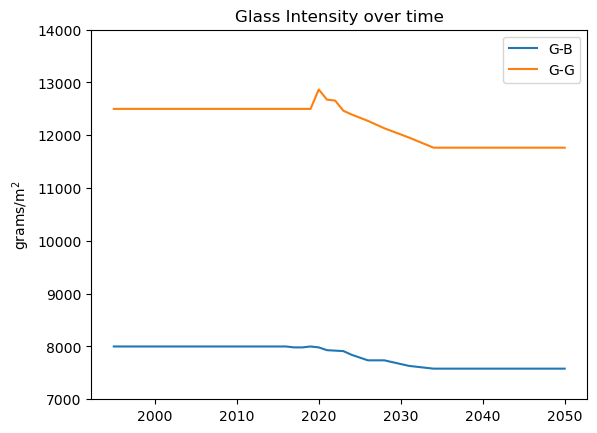

In [93]:
plt.plot(g_b_glassMass, label='G-B')
plt.plot(g_g_glassMass, label='G-G')
plt.title('Glass Intensity over time')
plt.ylabel('grams/m$^2$')
plt.ylim(7000,14000)
plt.legend()

## Create a Single Average glass weight by marketshare as well
In addition, here we will also use the module conformation marketshare to create a single average of glass intentsity per year. Ideally, we will only use this for demonstration/graphing, use the individual g-g and g-b weights in respective baselines to improve model accuracy.

In [96]:
g_b_market_mass = glass_fract['Module conformation marketshare']['glass-backsheet']*g_b_glassMass
g_g_market_mass = glass_fract['Module conformation marketshare']['glass-glass']*g_g_glassMass
avg_module_glassMass = g_g_market_mass + g_b_market_mass

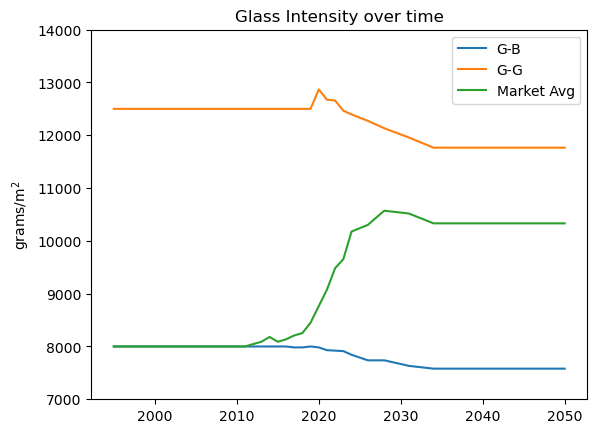

In [97]:
plt.plot(g_b_glassMass, label='G-B')
plt.plot(g_g_glassMass, label='G-G')
plt.plot(avg_module_glassMass, label='Market Avg')

plt.title('Glass Intensity over time')
plt.ylabel('grams/m$^2$')
plt.ylim(7000,14000)
plt.legend()

In [106]:
output_glass_gmp2_baselines = pd.DataFrame([avg_module_glassMass,g_b_glassMass,g_g_glassMass], index=['market_avg_module','G-B','G-G']).T
output_glass_gmp2_baselines.to_csv(os.path.join(supportMatfolder, 'output_glass_gmp2_baselines.csv'))